In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrisonlou/imu-glove", output_dir="./imu_data")

print("Path to dataset files:", path)

Path to dataset files: ./imu_data


In [30]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Stationary

### Load Data

In [31]:
stationary_df = pl.read_csv("./imu_data/rosbag/data/data_clean/rosbag2_2023_02_10-06_45_38_data.csv")

stationary_df.head()

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu0_orientation_x,Imu0_orientation_y,Imu0_orientation_z,Imu0_orientation_w,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z,Imu1_orientation_x,Imu1_orientation_y,Imu1_orientation_z,Imu1_orientation_w,Imu2_linear_accleration_x,Imu2_linear_accleration_y,Imu2_linear_accleration_z,Imu2_angular_velocity_x,Imu2_angular_velocity_y,Imu2_angular_velocity_z,Imu2_orientation_x,Imu2_orientation_y,Imu2_orientation_z,Imu2_orientation_w,imu0_to_imu1_translation_x,imu0_to_imu1_translation_y,imu0_to_imu1_translation_z,imu0_to_imu1_rotation_x,imu0_to_imu1_rotation_y,imu0_to_imu1_rotation_z,imu0_to_imu1_rotation_w,imu0_to_imu2_translation_x,imu0_to_imu2_translation_y,imu0_to_imu2_translation_z,imu0_to_imu2_rotation_x,imu0_to_imu2_rotation_y,imu0_to_imu2_rotation_z,imu0_to_imu2_rotation_w
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.6760e9,2.5,1.62,9.17,0.09,0.04,0.01,-0.126207,0.094461,-0.314152,-0.936193,-8.98,3.47,1.64,0.06,-0.14,0.03,0.620982,-0.077213,-0.749014,0.217709,-8.46,4.21,0.26,0.14,0.11,0.02,-0.144561,-0.869124,0.168527,-0.441954,0.951256,1.910681,-0.258669,0.0,0.0,0.0,1.0,-0.690498,-1.45009,1.429319,0.0,0.0,0.0,1.0
1.6760e9,2.45,1.63,9.17,0.1,0.04,0.0,-0.124434,0.093865,-0.314841,-0.936259,-9.01,3.45,1.73,0.06,-0.14,0.05,0.621111,-0.077753,-0.749309,0.216129,-8.45,4.26,0.33,0.15,0.11,0.02,-0.146901,-0.868752,0.169273,-0.44163,0.952718,1.910037,-0.258044,0.0,0.0,0.0,1.0,-0.685158,-1.459048,1.422757,0.0,0.0,0.0,1.0
1.6760e9,2.52,1.61,9.16,0.1,0.03,0.0,-0.124836,0.09598,-0.315462,-0.935782,-9.04,3.42,1.72,0.07,-0.14,-0.0,0.621324,-0.077862,-0.749799,0.213765,-8.49,4.23,0.22,0.14,0.1,0.0,-0.148902,-0.868369,0.170042,-0.441417,0.946426,1.913602,-0.254762,0.0,0.0,0.0,1.0,-0.686516,-1.463431,1.417592,0.0,0.0,0.0,1.0
1.6760e9,2.49,1.55,9.14,0.11,0.02,0.01,-0.12259,0.097031,-0.316984,-0.935456,-8.99,3.45,1.73,0.06,-0.14,0.01,0.621676,-0.078265,-0.750455,0.210263,-8.42,4.25,0.26,0.14,0.1,0.01,-0.152598,-0.86766,0.171241,-0.441085,0.94436,1.915104,-0.25112,0.0,0.0,0.0,1.0,-0.682205,-1.477085,1.40546,0.0,0.0,0.0,1.0
1.6760e9,2.53,1.58,9.23,0.11,0.05,0.01,-0.121883,0.097969,-0.317809,-0.935171,-9.05,3.43,1.68,0.08,-0.13,0.01,0.622048,-0.078741,-0.75063,0.208354,-8.46,4.22,0.3,0.15,0.11,0.02,-0.154696,-0.867306,0.171908,-0.440791,0.941121,1.917111,-0.247947,0.0,0.0,0.0,1.0,-0.680623,-1.483638,1.399311,0.0,0.0,0.0,1.0


In [32]:
def get_column_combos(imus, dims, readings):
    columns = [f"Imu{im}_{read}_{dim}" for im in imus for read in readings for dim in dims]
    return columns

imus = [0, 1]
dims = ["x", "y", "z"]
readings = ["linear_accleration", "angular_velocity"]

stationary_df = stationary_df.select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

stationary_df.head()

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-10 06:45:43.162601,2.5,1.62,9.17,0.09,0.04,0.01,-8.98,3.47,1.64,0.06,-0.14,0.03
2023-02-10 06:45:43.195087,2.45,1.63,9.17,0.1,0.04,0.0,-9.01,3.45,1.73,0.06,-0.14,0.05
2023-02-10 06:45:43.228188,2.52,1.61,9.16,0.1,0.03,0.0,-9.04,3.42,1.72,0.07,-0.14,-0.0
2023-02-10 06:45:43.285168,2.49,1.55,9.14,0.11,0.02,0.01,-8.99,3.45,1.73,0.06,-0.14,0.01
2023-02-10 06:45:43.314377,2.53,1.58,9.23,0.11,0.05,0.01,-9.05,3.43,1.68,0.08,-0.13,0.01


### Visual

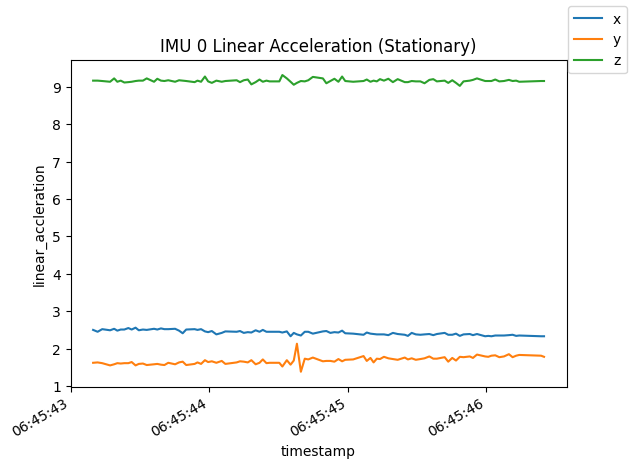

In [41]:
def plot_readings(df, imu: str, title: str, reading: str, dims: list[str] = ["x", "y", "z"]):
    fig, ax = plt.subplots()

    for dim in dims:
        ax.plot(
            df["timestamp"],
            df[f"{imu}_{reading}_{dim}"],
            label=dim
        )

    ax.set_title(title) # 'IMU 0 Linear Acceleration (Stationary)'
    ax.set_xlabel('timestamp')
    ax.set_ylabel(reading)
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
    fig.autofmt_xdate()
    fig.legend()

    plt.show()

plot_readings(
    stationary_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Stationary)",
    "linear_accleration"
)

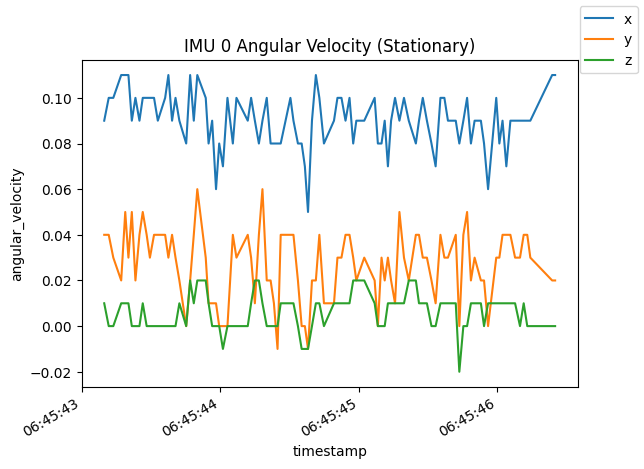

In [42]:
plot_readings(
    stationary_df,
    "Imu0",
    "IMU 0 Angular Velocity (Stationary)",
    "angular_velocity"
)

## Slide Up

### Load Data

In [35]:
slide_up_df = pl.read_csv("./imu_data/rosbag/data/data_clean/rosbag2_2023_02_10-07_52_42_data.csv").select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

slide_up_df.head()

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-10 07:52:45.791739,0.57,1.04,9.44,0.24,-0.09,0.02,-9.0,1.82,2.91,0.08,-0.16,0.02
2023-02-10 07:52:45.816029,0.71,1.18,9.44,0.02,0.13,-0.01,-9.14,1.92,3.08,0.08,-0.12,-0.0
2023-02-10 07:52:45.849457,0.78,1.24,9.54,0.07,0.03,0.0,-9.35,2.02,3.1,0.06,-0.15,0.0
2023-02-10 07:52:45.877149,0.73,1.17,9.57,0.16,-0.03,0.02,-9.15,1.97,3.11,0.06,-0.17,0.03
2023-02-10 07:52:45.946374,0.57,1.03,9.35,0.14,-0.02,0.02,-8.93,1.87,3.0,0.05,-0.13,-0.0


### Visual

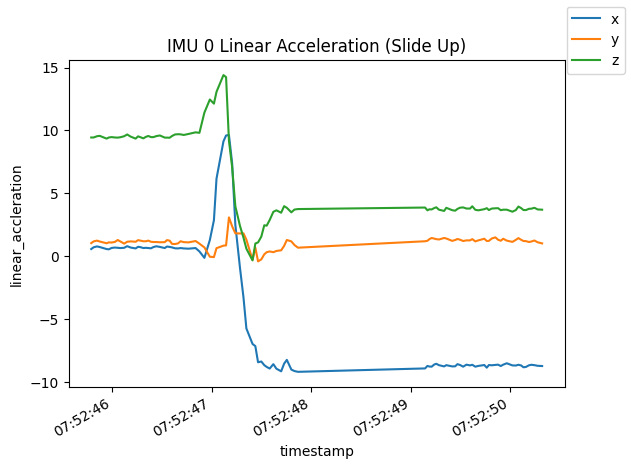

In [43]:
plot_readings(
    slide_up_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Slide Up)",
    "linear_accleration"
)

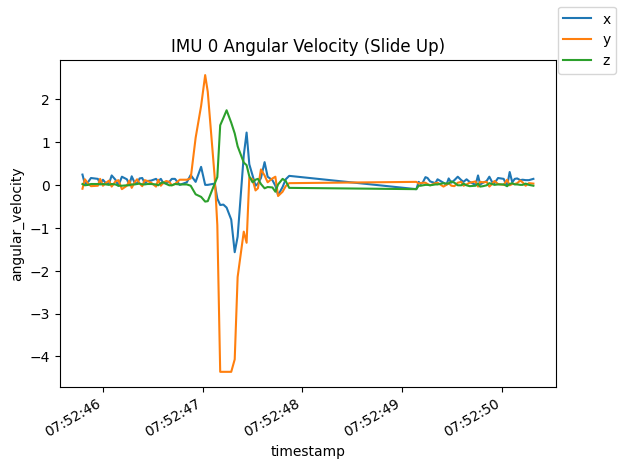

In [44]:
plot_readings(
    slide_up_df,
    "Imu0",
    "IMU 0 Angular Velocity (Slide Up)",
    "angular_velocity"
)

## Slide Down

### Load Data

In [38]:
slide_down_df = pl.read_csv("./imu_data/rosbag/data/data_clean/rosbag2_2023_03_02-05_19_45_data.csv").select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

slide_down_df.head()

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-03-02 05:19:48.264166,-2.23,5.5,7.67,0.1,0.03,0.02,-7.88,5.79,0.74,0.05,-0.14,0.02
2023-03-02 05:19:48.287537,-2.25,5.48,7.62,0.1,0.02,0.0,-7.69,5.67,0.75,0.07,-0.15,0.02
2023-03-02 05:19:48.310224,-2.23,5.49,7.62,0.09,0.03,-0.0,-7.73,5.83,0.81,0.09,-0.13,0.01
2023-03-02 05:19:48.333418,-2.21,5.54,7.66,0.07,0.04,0.01,-7.96,5.94,0.85,0.05,-0.13,0.01
2023-03-02 05:19:48.356987,-2.22,5.58,7.62,0.1,0.01,0.02,-7.66,5.75,0.63,0.04,-0.15,0.03


### Visual

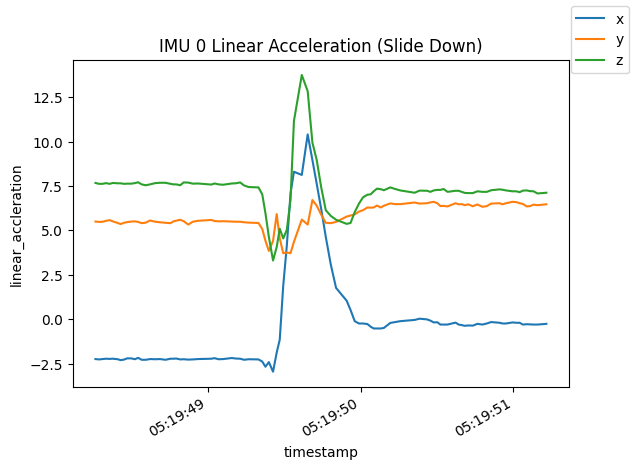

In [45]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Slide Down)",
    "linear_accleration"
)

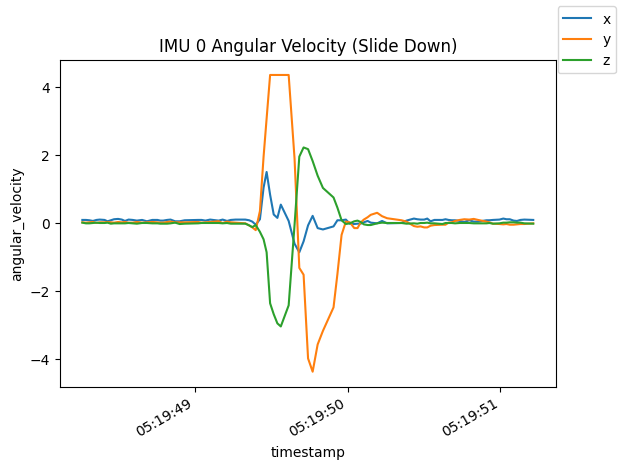

In [46]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Angular Velocity (Slide Down)",
    "angular_velocity"
)